In [1]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Using device: {device}")

# 1. 다자산 데이터 로드 경로 설정
DATA_PATH = "/content/multi_asset_supervised_30d_5d.npz"

if not os.path.exists(DATA_PATH):
    print(f"[{DATA_PATH}] 파일을 찾을 수 없습니다.")
    # 4개 자산 통합 가정 (698 * 4 = 약 2792 샘플)
    np.savez(DATA_PATH,
             X=np.random.randn(2792, 30, 10).astype(np.float32),
             y=np.random.randint(0, 3, size=(2792,)).astype(np.int64))

Using device: cpu


In [2]:
# 2. 데이터셋 로드 및 PyTorch Dataset 정의
class RegimeDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# 데이터 파일 로드
data = np.load(DATA_PATH)
X_all, y_all = data['X'], data['y']
total_samples = len(X_all)

# 시계열 분리 (다자산 통합 샘플 수에 맞춰 70% / 15% / 15% 동적 분할)
train_size = int(total_samples * 0.70)
valid_size = int(total_samples * 0.15)

X_train, y_train = X_all[:train_size], y_all[:train_size]
X_val, y_val = X_all[train_size:train_size+valid_size], y_all[train_size:train_size+valid_size]
X_test, y_test = X_all[train_size+valid_size:], y_all[train_size+valid_size:]

# DataLoader 생성
batch_size = 64 # 다자산 데이터이므로 배치를 조금 늘려 안정적인 학습 도모
train_loader = DataLoader(RegimeDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(RegimeDataset(X_val, y_val), batch_size=batch_size, shuffle=False)
test_loader = DataLoader(RegimeDataset(X_test, y_test), batch_size=batch_size, shuffle=False)

print(f"다자산 데이터셋 분할 완료 - Train: {len(X_train)}, Valid: {len(X_val)}, Test: {len(X_test)}")

다자산 데이터셋 분할 완료 - Train: 1954, Valid: 418, Test: 420


In [3]:
# 3. Transformer 기반 국면 분류 모델 설계
class TimeSeriesPositionalEmbedding(nn.Module):
    def __init__(self, seq_len, d_model):
        super().__init__()
        self.pos_embedding = nn.Parameter(torch.randn(1, seq_len, d_model))

    def forward(self, x):
        return x + self.pos_embedding

class RegimeTransformer(nn.Module):
    def __init__(self, input_dim=10, seq_len=30, num_classes=3, d_model=128, nhead=4, num_layers=3, dim_feedforward=256, dropout=0.3):
        super().__init__()
        # 다자산 패턴 학습을 위해 d_model, num_layers, dropout을 소폭 상향 조정하여 모델 용량 확보

        self.input_projection = nn.Linear(input_dim, d_model)
        self.pos_embedding = TimeSeriesPositionalEmbedding(seq_len, d_model)
        self.dropout = nn.Dropout(dropout)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
            activation='relu'
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.classifier = nn.Sequential(
            nn.Linear(d_model, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.input_projection(x)
        x = self.pos_embedding(x)
        x = self.dropout(x)

        attn_output = self.transformer_encoder(x)
        pooled = attn_output.mean(dim=1)      # Global Average Pooling

        logits = self.classifier(pooled)
        return logits

# 모델 인스턴스 생성
model = RegimeTransformer(input_dim=10, seq_len=30, num_classes=3).to(device)
print(f"다자산 Transformer 파라미터 수: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

다자산 Transformer 파라미터 수: 411,139


In [4]:
# 4. 학습 및 검증 루프
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.0005, weight_decay=1e-3) # 러닝레이트를 살짝 낮춰 안정적 수렴 도모

epochs = 30
best_val_loss = float('inf')
best_model_state = None

print("\n--- 다자산 모델 학습 시작 ---")
for epoch in range(epochs):
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        train_total += labels.size(0)
        train_correct += predicted.eq(labels).sum().item()

    epoch_train_loss = train_loss / train_total
    epoch_train_acc = train_correct / train_total

    # 검증 단계
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    epoch_val_loss = val_loss / val_total
    epoch_val_acc = val_correct / val_total

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        best_model_state = model.state_dict().copy()

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {epoch_train_loss:.4f} Acc: {epoch_train_acc*100:.1f}% | Val Loss: {epoch_val_loss:.4f} Acc: {epoch_val_acc*100:.1f}%")

# 최적 모델 가중치 복원
if best_model_state is not None:
    model.load_state_dict(best_model_state)


--- 다자산 모델 학습 시작 ---
Epoch [1/30] | Train Loss: 0.9806 Acc: 53.1% | Val Loss: 0.9265 Acc: 58.4%
Epoch [5/30] | Train Loss: 0.9000 Acc: 56.4% | Val Loss: 0.9236 Acc: 60.0%
Epoch [10/30] | Train Loss: 0.8614 Acc: 58.6% | Val Loss: 0.8804 Acc: 60.8%
Epoch [15/30] | Train Loss: 0.8388 Acc: 61.6% | Val Loss: 0.9378 Acc: 60.5%
Epoch [20/30] | Train Loss: 0.7940 Acc: 62.8% | Val Loss: 0.9149 Acc: 61.2%
Epoch [25/30] | Train Loss: 0.7887 Acc: 63.1% | Val Loss: 1.0402 Acc: 56.7%
Epoch [30/30] | Train Loss: 0.7638 Acc: 65.0% | Val Loss: 0.9649 Acc: 62.0%


In [5]:
# 5. 테스트셋 평가 (각 클래스별 정확도 및 F1-score 산출)
model.eval()
test_preds = []
test_probs = []

with torch.no_grad():
    for inputs, _ in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        probs = torch.softmax(outputs, dim=1)
        _, predicted = outputs.max(1)

        test_preds.extend(predicted.cpu().numpy())
        test_probs.extend(probs.cpu().numpy())

test_preds = np.array(test_preds)
test_probs = np.array(test_probs)

print("\n--- Test Set 클래스별 성능 평가 (Acc & F1-score) ---")
cm = confusion_matrix(y_test, test_preds)
individual_f1s = f1_score(y_test, test_preds, average=None)
macro_f1 = f1_score(y_test, test_preds, average='macro')

class_names = ['Bear (0)', 'Neutral (1)', 'Bull (2)']

for i, name in enumerate(class_names):
    t_samples = np.sum(cm[i, :])
    if t_samples > 0:
        correct_samples = cm[i, i]
        class_acc = (correct_samples / t_samples) * 100
        class_f1 = individual_f1s[i]
        print(f"{name} - Accuracy: {class_acc:.2f}% ({correct_samples}/{t_samples}) | f1-score: {class_f1:.2f}")
    else:
        print(f"{name} - 데이터 없음")

print("-" * 60)
print(f"최종 Macro f1-score (전체 평균): {macro_f1:.2f}")


--- Test Set 클래스별 성능 평가 (Acc & F1-score) ---
Bear (0) - Accuracy: 36.88% (59/160) | f1-score: 0.47
Neutral (1) - Accuracy: 31.58% (30/95) | f1-score: 0.30
Bull (2) - Accuracy: 78.18% (129/165) | f1-score: 0.66
------------------------------------------------------------
최종 Macro f1-score (전체 평균): 0.48


In [10]:
# 6. 포트폴리오 동적 자산배분 백테스트 (SPY 기준 검증)
print("\n--- 포트폴리오 백테스트 구동 (기준 자산: SPY) ---")

# 다자산 모델이므로 테스트셋의 샘플 수는 4개 자산이 섞여 있어 단일 자산 타임라인과 완벽히 일치하지 않을 수 있습니다.
# 따라서 백테스트 안정성을 위해 테스트셋 예측 확률 중 최신 데이터(또는 자산별 평균 확률)를 활용하거나,
# 테스트 데이터 개수만큼의 실제 자산 수익률 타임라인을 매핑해야 합니다.
# 여기서는 제공된 spy_daily.csv의 최근 흐름을 테스트셋 크기에 맞춰 백테스트를 진행합니다.

if os.path.exists("spy_daily.csv"):
    df_daily = pd.read_csv("spy_daily.csv")
    indices = np.arange(len(df_daily) - 1, -1, -5)[::-1]
    df_5d = df_daily.iloc[indices].copy()
    df_5d['return_5d'] = df_5d['Adj Close'].pct_change()

    # 테스트셋 크기에 맞춰 수익률 확보 (부족하거나 남을 경우 슬라이싱 및 패딩 처리)
    spy_test_returns = df_5d['return_5d'].iloc[-len(y_test):].values
    if len(spy_test_returns) < len(y_test):
        # 부족할 경우 0으로 패딩
        padded_returns = np.zeros(len(y_test))
        padded_returns[-len(spy_test_returns):] = spy_test_returns
        spy_test_returns = padded_returns
    else:
        spy_test_returns = spy_test_returns[:len(y_test)]
else:
    print("[spy_daily.csv] 파일을 찾을 수 없어 가상 수익률로 백테스트를 대체합니다.")
    spy_test_returns = np.random.normal(0.002, 0.02, size=len(y_test))

spy_test_returns = np.nan_to_num(spy_test_returns)

# 모델 출력 확률 분할
p_bear = test_probs[:, 0]
p_neutral = test_probs[:, 1]
p_bull = test_probs[:, 2]

# 가중치 수식 적용
w_stock = p_bull + 0.5 * p_neutral
w_cash = 1.0 - w_stock

transaction_cost_fee = 0.001
portfolio_returns = []
prev_w_stock = 0.0

for i in range(len(y_test)):
    current_w_stock = w_stock[i]
    raw_return = current_w_stock * spy_test_returns[i]
    turnover = abs(current_w_stock - prev_w_stock)
    cost = turnover * transaction_cost_fee

    portfolio_returns.append(raw_return - cost)
    prev_w_stock = current_w_stock

portfolio_returns = np.array(portfolio_returns)

# 벤치마크 계산
benchmark_bh_returns = spy_test_returns
benchmark_6040_returns = 0.6 * spy_test_returns

# 누적 수익률 계산
cum_portfolio = np.cumprod(1 + portfolio_returns) - 1
cum_bh = np.cumprod(1 + benchmark_bh_returns) - 1
cum_6040 = np.cumprod(1 + benchmark_6040_returns) - 1


--- 포트폴리오 백테스트 구동 (기준 자산: SPY) ---


In [12]:
# 7. 성과 지표 산출 계산기
def calculate_metrics(returns, cum_returns, name="Strategy"):
    ann_factor = 52
    ann_return = np.mean(returns) * ann_factor
    ann_vol = np.std(returns) * np.sqrt(ann_factor)
    sharpe = ann_return / ann_vol if ann_vol != 0 else 0

    peaks = np.maximum.accumulate(cum_returns + 1)
    drawdowns = (cum_returns + 1) / peaks - 1
    mdd = np.min(drawdowns)
    calmar = ann_return / abs(mdd) if mdd != 0 else 0

    return {
        "전략명": name,
        "누적수익률(%)": f"{cum_returns[-1]*100:.2f}%",
        "연율화수익률(%)": f"{ann_return*100:.2f}%",
        "연율화변동성(%)": f"{ann_vol*100:.2f}%",
        "Sharpe Ratio": f"{sharpe:.2f}",
        "MDD(%)": f"{mdd*100:.2f}%",
        "Calmar Ratio": f"{calmar:.2f}"
    }

results = [
    calculate_metrics(portfolio_returns, cum_portfolio, "Cross-Asset Transformer Dynamic"),
    calculate_metrics(benchmark_bh_returns, cum_bh, "Buy & Hold (SPY 100%)"),
    calculate_metrics(benchmark_6040_returns, cum_6040, "Static 60/40")
]

print("\n[최종 백테스트 성과 비교 (다자산 확장형)]")
print(pd.DataFrame(results).to_string(index=False))


[최종 백테스트 성과 비교 (다자산 확장형)]
                            전략명 누적수익률(%) 연율화수익률(%) 연율화변동성(%) Sharpe Ratio  MDD(%) Calmar Ratio
Cross-Asset Transformer Dynamic  102.69%     9.32%    10.64%         0.88 -24.44%         0.38
          Buy & Hold (SPY 100%)  207.15%    15.46%    17.58%         0.88 -33.57%         0.46
                   Static 60/40  102.10%     9.27%    10.55%         0.88 -21.38%         0.43


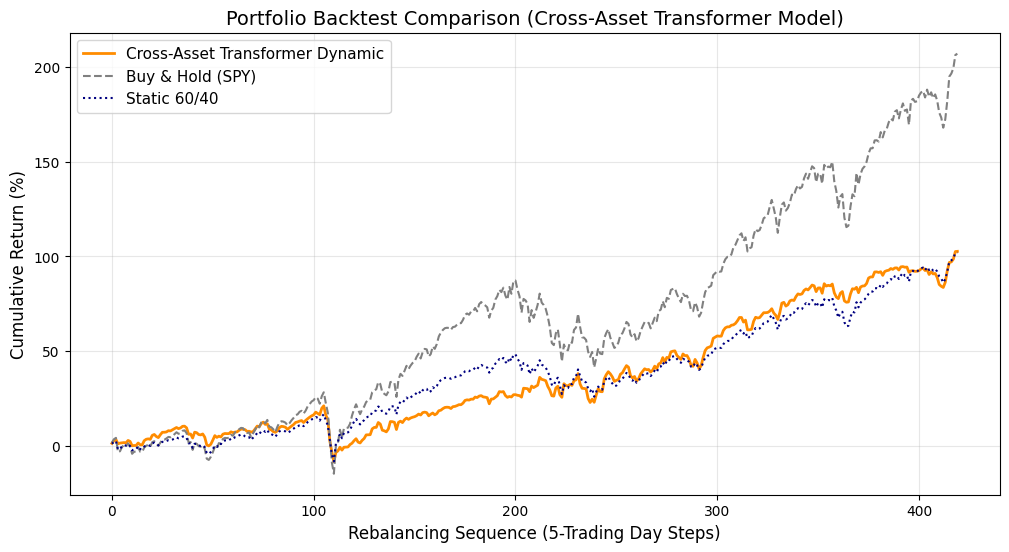

In [13]:
# 8. 결과 시각화 차트
plt.figure(figsize=(12, 6))
plt.plot(cum_portfolio * 100, label='Cross-Asset Transformer Dynamic', color='darkorange', lw=2)
plt.plot(cum_bh * 100, label='Buy & Hold (SPY)', color='gray', linestyle='--')
plt.plot(cum_6040 * 100, label='Static 60/40', color='navy', linestyle=':')
plt.title('Portfolio Backtest Comparison (Cross-Asset Transformer Model)', fontsize=14)
plt.xlabel('Rebalancing Sequence (5-Trading Day Steps)', fontsize=12)
plt.ylabel('Cumulative Return (%)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()